# Create the misalignment estimates used for the State of the Tax Justice
- To do: write summary of what this code is doing based on Methology_note_commented

Load packages

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tjn_tools
from tjn_tools.data_processing import *

#Imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

#Linear regression
from sklearn.linear_model import LassoCV, Lasso, LinearRegression 
#Not used, worse: from sklearn.ensemble import GradientBoostingRegressor
#Not used, worse: from sklearn.svm import SVR

#Model selection
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
#from sklearn.inspection import plot_partial_dependence

#Main model
from sklearn.ensemble import HistGradientBoostingRegressor

from itertools import permutations, product
from scipy.stats import randint
import pickle

from config_new import YEAR_CBCR

Adjust settings

In [3]:
pd.options.mode.chained_assignment = None  # default='warn'
sns.set(font_scale=1.2,style="whitegrid")
%matplotlib inline
pd.set_option('display.max_columns', 100)

path_files = "../../data/raw/"
path_files_final = "../../data/final/estimations/" # path for final datasets
path_files_temp = "../../data/intermediate/"
path_figures = "../../data/intermediate/"

#Input from data cleaning code
etr_file = f"{path_files_final}{YEAR_CBCR}_cbcr_etr_rates_new.xlsx"
df_pairs_file = f"{path_files_final}{YEAR_CBCR}_df_pairs_new.tsv"
df_fin_file = f"{path_files_final}{YEAR_CBCR}_df_fin_new.tsv"
d_groups2countries_file = f"{path_files_final}{YEAR_CBCR}_d_groups2countries_new.dump"
iso3_to_wages_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_wages_new.dump"
iso3_to_cit_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_cit_new.dump"

#Output files
final_data_output = f"{path_files_temp}{YEAR_CBCR}_replicates_new.csv"
iso3_to_count_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_count_new.dump"
iso3_to_dom_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_dom_new.dump"

In [4]:
# min_samples_leaf = 20
# learning_rate = 0.2 #0.1
# l2_regularization = 125# 100

#Estimated beloe
metaparameters  = {
    "ln_pi": {'l2_regularization': 1000.0, 'learning_rate': 0.1366666666666667, 'min_samples_leaf':20 },
    "ln_emp": {'l2_regularization': 15.848931924611133, 'learning_rate': 0.16833333333333336, 'min_samples_leaf': 20},
    "ln_revt": {'l2_regularization': 158.48931924611142, 'learning_rate': 0.07333333333333333 , 'min_samples_leaf': 20},
    "ln_t_at": {'l2_regularization': 158.48931924611142, 'learning_rate': 0.07333333333333333, 'min_samples_leaf': 20}
}

In [5]:
def impute(df,columns,verbose=0):
    #BayesianRidge performs as well as missForest (R)
    values = df[columns].values
    estimator = BayesianRidge()#(n_estimators=10, random_state=0, bootstrap=True, n_jobs=-1)
    imp = IterativeImputer(max_iter=100, estimator = estimator,verbose=verbose)
    imp.fit(values)
    new_values = imp.transform(values)

    #Replace with full info
    for i,col in enumerate(columns):
        df[col] = new_values[:,i]
    
    return df

# 2. Gravity model for sales, employees and profits

In [6]:
df_etrs = pd.read_excel(etr_file)

In [7]:
df_pairs = pd.read_csv(df_pairs_file,sep="\t")
df_fin =  pd.read_csv(df_fin_file,sep="\t")

d_groups2countries = pickle.load(open(d_groups2countries_file,"rb+"))

In [8]:
df_fin["etr"] = df_fin["txc"]/df_fin['pi']

#ETR by pair of countries
iso3_to_etr_pair = df_fin.set_index(["iso3_o",'iso3_d'])["etr"].to_dict()

In [9]:
# df_fin.loc[df_fin["iso3_o"]=="CHN"].sort_values(by="pi",ascending=False)

### 2.1 Split models by domestic and foreign activities
- "domestic_variables" imports several variables twice. However, I keep it this way as the later code creates problems if not. I delete these columns later to avpid duplicates when I need to concatenate the data frame later
- check if FDI_inward is similar to fdi_inflows_wdi_o

In [10]:
#cols javier (some not in our datasets anymore) = ['iso3_o','txc','ln_pi', 'ln_emp', 'ln_revt','ln_t_at','ln_cit_revenue_o', 'gdpcap_pc_o', 'gatt_o', 'wto_o', 'entry_proc_o', 'entry_time_o', 'entry_tp_o', 'physicians_per_1000_o', 'nurses_per_1000_o', 'region_tjn_o', 'eu28_o', 'oecd_o', 'ukt_o', 'cit_o', 'ratings_o', 'english_o', 'Total FSI_o', 'ln_accountant_o', 'ln_all_tax_o', 'ln_banker_o', 'ln_ceo_o', 'ln_cfo_o', 'ln_coo_o', 'ln_cxo_o', 'ln_engineer_o', 'ln_other_corporate_o', 'ln_physician_o', 'ln_tax_compliance_audit_o', 'ln_transfer_pricing_o', 'ln_wealth_o', 'ln_audience_o', 'ln_consumption_o', 'ln_gfcf_o', 'ln_population_o', 'ln_uhnwi_o', 'ln_BIS_o', 'ln_finance_o', 'governance_o', 'ln_gdp_pc_o', 'tax_complex_o', 'cthi_o', 'etr_real_o', 'ln_etr_real_o', 'ln_pop_o', 'ln_gdp_o', 'ln_gdp_pc_o', 'ln_gdp_ppp_o', 'ln_pop_pwt_o', 'ln_gdp_ppp_pwt_o', 'ln_entry_cost_o', 'ln_ip_payments_wb_o', 'ln_ip_receipts_wb_o', 'ln_fdi_inflows_wdi_o', 'ln_total_reserves_o', 'ln_number_of_new_businesses_registered_o', 'ln_Imports_wb_o', 'ln_exports_o', 'ln_gdp_pc_o', 'ln_gdp_deflator_o', 'ln_govt_exp_educ_gdp_o', 'ln_health_exp_gdp_o', 'ln_greenfieldfdi_outward_o', 'ln_greenfieldfdi_inward_o', 'ln_resource_taxes_o', 'ln_total_taxes_revenue_o', 'ln_who_gvt_health_expenditure_o', 'ln_month_wage_o', 'ln_gdp_o', 'ln_population_o', 'ln_physicians_o', 'ln_nurses_o', 'ln_n_companies_orb_o', 'gdp_ppp_o', 'pop_pwt_o', 'gdp_ppp_pwt_o', 'ln_cit_o']
domestic_variables = ['iso3_o','txc','ln_pi', 'ln_emp', 'ln_revt','ln_t_at','ln_cit_revenue_o', 'ln_gdppc_o', 'physicians_per_1000_o', 'nurses_per_1000_o', 'region_tjn_o', 'eu28_o', 'oecd_o', 'ukt_o', 'cit_o', 'ratings_o', 'english_o', 'Total FSI_o', 'ln_accountant_o', 'ln_all_tax_o', 'ln_banker_o', 'ln_ceo_o', 'ln_cfo_o', 'ln_coo_o', 'ln_cxo_o', 'ln_engineer_o', 'ln_other_corporate_o', 'ln_physician_o', 'ln_tax_compliance_audit_o', 'ln_transfer_pricing_o', 'ln_wealth_o', 'ln_audience_o', 'ln_consumption_o', 'ln_gfcf_o', 'ln_population_o', 'ln_uhnwi_o', 'ln_BIS_o', 'ln_finance_o', 'governance_o', 'ln_gdp_pc_o', 'tax_complex_o', 'cthi_o', 'etr_real_o', 'ln_etr_real_o', 'ln_gdp_o', 'ln_population_o','ln_gdp_o', 'ln_gdp_pc_o','ln_ip_payments_o', 'ln_ip_receipts_o', 'ln_fdi_inward', 'ln_new_businesses_registered_o', 'ln_imports_o', 'ln_exports_o', 'ln_gdp_pc_o','ln_gdp_deflator_o', 'ln_govt_exp_educ_gdp_o', 'ln_health_exp_gdp_o', 'ln_greenfieldfdi_outward_o', 'ln_greenfieldfdi_inward_o', 'ln_resource_taxes_o', 'ln_total_taxes_revenue_o', 'ln_who_gvt_health_expenditure_o', 'ln_month_wage_o', 'ln_gdp_o','ln_physicians_o', 'ln_nurses_o', 'ln_n_companies_orb_o', 'ln_cit_o']
df_domestic = df_pairs.loc[df_pairs["iso3_o"]==df_pairs["iso3_d"], domestic_variables]
df_foreign = df_pairs.loc[df_pairs["iso3_o"]!=df_pairs["iso3_d"]]

Check how many missing values the relevant variables have

In [11]:
for i in df_pairs.count().items():
    if i[1]<2800:
        print(i)

('txc', 2355)
('ln_emp', 2353)
('ln_revt', 2344)
('ln_pi', 1930)
('ln_t_at', 2350)


### 2.2 Find best regularization parameter

In [12]:
scorer = make_scorer(r2_score)

In [13]:
def find_best_model(est,clf,df):
    
    for var in ['ln_pi','ln_emp',"ln_revt","ln_t_at"]:
        df = df.copy().dropna(subset=["ln_pi",var])
        print(var)
        y = df[var].values
        a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
        columns = np.array(a.columns)[a.dtypes!=object]
#         print(columns)
        X = df[columns].values
#         display(df[columns].describe())
        print(y.min(),y.mean(),y.max(),y.std())


        search = clf.fit(X,y)
        print(var, search.best_params_)
        try:
            plt.plot(search.param_grid["alpha"],search.cv_results_["mean_test_score"])
            plt.show()
        except:
            pass            

### 2.3 Test algorithm
- Out of sample prediction power
- There is just a function programmed here to plot predictive power which will be used later

In [14]:
def plot_r2(clf,df,var,columns=None):
    df = df.dropna(subset=["ln_pi"]).copy()
    if columns is None:
        a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
        columns = np.array(a.columns)[a.dtypes!=object]

    X = df[columns].values
    y = df[var].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
    
    #return    X_train, X_test, y_train, y_test  
    
    clf.fit(X_train,y_train)
    profits = clf.predict(X_test)
    try:
        print([_ for _ in sorted(zip(clf.coef_,columns)) if _[0]!=0])
    except:
        pass
    plt.plot(np.exp(y_train),np.exp(clf.predict(X_train)),".",color="lightgray")
    plt.plot(np.exp(y_test),np.exp(profits),".")
    plt.xscale("log")
    plt.yscale("log")
    # plt.title(var)
    plt.xlabel("CbCR")
    plt.ylabel("Predicted")
    
    valid = np.isfinite(y_test) & np.isfinite(profits)
#     print(type(y_test),type(profits))
    r2 = r2_score(y_test[valid],profits[valid])
    plt.title("Var: {} R2: {:.2f}".format(var,r2))

    sns.despine(bottom=True,left=True)

### 2.5 Adjust to sum up to totals
- again, I think this is just a function applied later

In [15]:
def plot_matching_foreign(df_fin,df_foreign,annot=False):
    #What we get vs what we know
    #x_fjt = df_fin.loc[df_fin["iso3_d"]=="FJT"].groupby("iso3_o").agg(lambda x: np.sum(x[x>0]))
    numeric_cols = df_fin.select_dtypes(include=np.number).columns
    x_fjt = df_fin.loc[df_fin["iso3_d"] == "FJT"].groupby("iso3_o")[numeric_cols].agg(lambda x: np.sum(x[x > 0]))
    x_other = df_fin.loc[(df_fin["iso3_o"]!=df_fin["iso3_d"])&(~df_fin["iso3_o"].isin(x_fjt.index))].groupby("iso3_o").agg(lambda x: np.sum(x[x>0]))
    x = pd.concat([x_fjt,x_other])
    
    a = df_foreign.groupby("iso3_o")["fitted_ln_pi"].agg(lambda x: np.sum(np.exp(x[x>0]))).to_dict()
    x["a"] = x.index.map(a)
    plt.plot(x["pi"],x["a"],"o")
    plt.plot([1E8,1E12],[1E8,1E12],"--",color="grey")
    plt.xscale("log")
    plt.yscale("log")
    if annot:
        for x_,y_,c_ in zip(x["pi"],x["a"],x.index):
            if (x_>0) and (y_>0): 
                plt.annotate(c_,(x_,y_))

    plt.xlabel("Real foreign profits")
    plt.ylabel("Predicted foreign profits")
    sns.despine(bottom=True,left=True)
    plt.show()
    
def adjust_total(c,data):
#     print(c)
    agg_data = df_fin.loc[df_fin["iso3_o"]==c].copy()
    if len(agg_data) == 0:
        return data
    
    if c in ["AUT","SWE","NOR"]:
        agg_data["iso3_d"] = agg_data["iso3_d"].replace("LAC","LAC_sca")
    agg_data = agg_data.set_index("iso3_d")
    

    cs_included = list(agg_data.index)
    for v in ["OAF","OAM","OAS","OTE","AFRIC","ASIAT","EUROP","LAC","LAC_sca","FJT","GRPS"]:
        if v in agg_data.index:
            
            if v == "GRPS":
                cs_group = d_groups2countries[v] - set(cs_included)
                truth_remove = 0
            elif (v == "FJT"): 
                if ("GRPS" in agg_data.index):
                    continue #otherwise fix it with GRPS
                #Countries in the main df but not in the original one and not fixed before = FJT
                cs_group = set(data["iso3_d"])- set(cs_included)
#                 print(cs_group)
                #Remove from FJT everything fixed before
                truth_remove = agg_data.loc[list(set(agg_data.index) - set(["FJT",c])),["revt","emp","pi","t_at"]].sum().fillna(0)

            else:
                cs_included += list(d_groups2countries[v])
                cs_group = d_groups2countries[v] - set(agg_data.index)
                truth_remove = 0

            truth = agg_data.loc[v,["revt","emp","pi","t_at"]] - truth_remove
#             print(v,truth.values)
    
            pred = np.exp(data.loc[data["iso3_d"].isin(cs_group),["fitted_ln_revt","fitted_ln_emp","fitted_ln_pi","fitted_ln_t_at"]])-1
            
            #If profits are negative in the region set them up to 0
            scale_by = pred.sum().values/truth.values
            scale_by[truth.values<0] = np.inf

            
            aux = 1+pred/scale_by
            data.loc[data["iso3_d"].isin(cs_group),["fitted_ln_revt","fitted_ln_emp","fitted_ln_pi","fitted_ln_t_at"]] = np.log(aux.apply(pd.to_numeric))
#             print((np.exp(data.loc[data["iso3_d"].isin(cs_group),["fitted_ln_revt","fitted_ln_emp","fitted_ln_pi","fitted_ln_t_at"]])-1).sum())
        else: #Countries where no operations
            if v == "GRPS":
                cs_group = d_groups2countries[v] - set(cs_included)
                
                data.loc[data["iso3_d"].isin(cs_group),["fitted_ln_revt","fitted_ln_emp","fitted_ln_pi","fitted_ln_t_at"]] = 0
                
                
    return data


def fill_and_adjust(df_domestic,df_foreign,bootstrap=False,output=False):
    df_domestic = fill_domestic(df_domestic,bootstrap=bootstrap,output=output) #bootstrap this would be a mistake with so few observations
    df_foreign = fill_foreign(df_foreign,bootstrap=bootstrap,output=output)
    if output:
        plot_matching_foreign(df_fin,df_foreign)


    ##Fix the ones we know
    for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
        df_domestic.loc[~np.isnan(df_domestic[var]),"fitted_"+var] = df_domestic.loc[~np.isnan(df_domestic[var]),var] 
        df_foreign.loc[~np.isnan(df_foreign[var]),"fitted_"+var] = df_foreign.loc[~np.isnan(df_foreign[var]),var] 
    
#         df_domestic.loc[df_domestic["ln_n_companies_orb_o"]==0,"fitted_"+var] = 0
#         df_foreign.loc[df_foreign["ln_n_companies_orb_o"]==0,"fitted_"+var] = 0

#     df_domestic.loc[df_domestic["ln_n_companies_orb_o"]==0,"ln_month_wage_o"] = 0
#     df_foreign.loc[df_foreign["ln_n_companies_orb_o"]==0,"ln_month_wage_d"] = 0

    if output:
        plot_matching_foreign(df_fin,df_foreign)

    df_foreign_fixed = [adjust_total(*_) for _ in df_foreign.groupby("iso3_o")]
    df_foreign_fixed = pd.concat(df_foreign_fixed)
#     df_foreign_fixed = df_foreign.copy()
    if output:
        plot_matching_foreign(df_fin,df_foreign_fixed)
    return df_domestic,df_foreign_fixed

### 2.6. Misalignment

In [16]:
def calculate_misalignment(df,
                           weights=[1/2,1/2,0,0], # default: half turnover, half employees
                           pi_var="pi",
                           weights_var = ["revt","empt","t_at","wages"]):
    """
    Calculate misalignment as a function of sales, employees, capital and wages
    
    In:
    df = data
    pi/rev/emp/cap/wages_var = variables with the profits/revenue/employees/capital/wages (None to discard)
    weights = weights of each of the variables. 
    
    Out:
    
    """
    
    #Make sure it is okay
    assert sum(weights)==1,"Weights need to sum up to 1"
    
    vars_keep = []
    weights_keep = []
    for i,var in enumerate(weights_var):
        if var is None:
            if weights[i] != 0:
                raise(Exception("Weight of None variable is nonzero"))
        else:
            if weights[i] > 0:
                vars_keep.append("share_{}".format(var))
                weights_keep.append(weights[i])
                df["share_{}".format(var)] = df[var]/df[var].sum()
    
#     print(weights_keep)
#     print(vars_keep)
    #Calculate the share of the economy
    df["share_economy"] = (df.loc[:,vars_keep]*weights_keep).sum(1,min_count=len(weights_keep))
    df["share_profits"] = df[pi_var]/df[pi_var].sum()
        
    #Theoretical profits
    df["pi_theo_mis"] = df[pi_var].sum()*df["share_economy"]
    
    #Misalignment
    df["misaligned_profits"] = df[pi_var]-df["pi_theo_mis"]

    #Threshold adjustment
    df.loc[(df["misaligned_profits"]>0)&(df["etr"]>0.25)&(df["Domestic"]==0),"misaligned_profits"] = 0
    #Correct for discrepancies
    x = df["misaligned_profits"]

    pos_pr = x[x>0].sum()
    previous_pr = -x[x<0].sum()
    print("Profit shifted {:2.1f} adjusted to {:2.1f}".format(previous_pr/1E9,pos_pr/1E9))
    df.loc[df["misaligned_profits"]<0,"misaligned_profits"] *= pos_pr/previous_pr



#     df["etr"] = df["p_iso3"].map(iso3_to_etr)
    
    #Total shifted (exclude resource-rich countries)
#     total_shifted = df.loc[(df["misaligned_profits"]>0)&(df["etr"]<0.15),"misaligned_profits"].sum() 
    
    return df


# 3 New model

In [17]:
df_fin_mis = df_fin.copy()
df_fin_mis = df_fin_mis.loc[df_fin_mis["iso3_d"].apply(get_iso3,print_failure=False).apply(lambda x: isinstance(x,str))]
df_fin_mis["r_iso3"] = df_fin_mis["iso3_o"]
df_fin_mis["p_iso3"] = df_fin_mis["iso3_d"]

In [18]:
#Count of companies (for later)
iso3_to_count = df_fin_mis.loc[df_fin_mis["iso3_o"]!=df_fin_mis["iso3_d"]].groupby("iso3_d")["iso3_o"].count().to_dict()
iso3_to_dom = df_fin_mis.loc[df_fin_mis["iso3_o"]==df_fin_mis["iso3_d"]].groupby("iso3_d")["iso3_o"].count().to_dict()
pickle.dump(iso3_to_count,open(iso3_to_count_output,"wb+"))
pickle.dump(iso3_to_dom,open(iso3_to_dom_output,"wb+"))

In [19]:
df_fin_mis.loc[df_fin_mis["iso3_d"]=="COL"]

,iso3_o,iso3_d,emp,pi,txc,revt,t_at,etr,r_iso3,p_iso3
6,ARG,COL,63.0,3.273618e+05,1.843421e+04,2.717070e+07,3.062656e+07,0.056311,ARG,COL
37,AUS,COL,2265.0,1.046685e+08,9.003756e+06,2.741706e+08,8.162444e+08,0.086022,AUS,COL
153,BMU,COL,4211.0,2.007488e+07,1.386932e+07,4.140278e+08,1.880513e+08,0.690879,BMU,COL
251,BRA,COL,7756.0,3.860565e+07,7.356638e+07,6.495458e+09,1.135041e+09,1.905586,BRA,COL
318,CHE,COL,25272.0,1.499427e+08,1.209448e+08,4.077526e+09,2.530888e+09,0.806607,CHE,COL
465,CYM,COL,142.0,3.598341e+06,1.396535e+06,5.049699e+07,4.629355e+06,0.388105,CYM,COL
623,DEU,COL,19784.0,1.827480e+08,8.822400e+07,3.951935e+09,1.109865e+09,0.482763,DEU,COL
772,DNK,COL,3567.0,2.347354e+07,8.344303e+06,2.967077e+08,1.271587e+08,0.355477,DNK,COL
894,ESP,COL,62400.0,4.775205e+08,1.782076e+08,5.717143e+09,2.838645e+09,0.373194,ESP,COL
1009,FRA,COL,92878.0,5.235957e+07,1.978815e+08,7.613998e+09,2.653181e+09,3.779281,FRA,COL


## Domestic profits

In [20]:
# Domestic profits: Use linear regressin
def fill_domestic(df_domestic,bootstrap=False,output=False,columns=None):
    dfs = []
    for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
        clf = LinearRegression()

        df = df_domestic.dropna(subset=[var]).copy()

        if columns is None:
            columns =["ln_BIS_o","ln_GDP_int_o","ln_POP_int_o","etr_real_o", "cit_o","ln_n_companies_orb_o",]
        
        if bootstrap:
            df = df.loc[df["ln_n_companies_orb_o"]>0].sample(frac=1,replace=True).copy()
        
        X = df.loc[df["ln_n_companies_orb_o"]>0,columns].values
        y = df.loc[df["ln_n_companies_orb_o"]>0,var].values
        if X.shape[0] == 0:
            print(f"No samples available for training {var}. Skipping...")
            return None

        clf.fit(X,y)
        if output:
            print(var,r2_score(y,clf.predict(X)))
            d_ = pd.DataFrame(zip(columns,clf.coef_),columns=["index",var])
            d_ = d_.set_index("index")
            dfs.append(d_)

        df_domestic["fitted_{}".format(var)] = clf.predict(df_domestic[columns].values)
        df_domestic.loc[df_domestic["ln_n_companies_orb_o"]==0,"fitted_{}".format(var)] = 0
        df_domestic[var[3:]] = np.exp(df_domestic["fitted_{}".format(var)])-1
    df_domestic["iso3_d"] = df_domestic["iso3_o"] 
    if output:
        display(pd.concat(dfs,axis=1))
    return df_domestic
 

In [21]:
from sklearn.model_selection import cross_validate

for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
    est = LinearRegression()#(alpha=0.03
    df = df_domestic.dropna(subset=[var]).copy()
    print(df.shape)
#     columns = list(set(cols)-set(['iso3_o','region_tjn_o','txc','ln_pi', 'ln_emp', 'ln_revt']))
    
    columns = np.array(df_domestic.columns)[df_domestic.dtypes!=object]
    columns = [_ for _ in columns if (_ not in df_fin.columns) and (_[3:] not in df_fin.columns)]
#     print(len(columns))
    
    df = impute(df,columns)
    
    
    columns =["ln_BIS_o","ln_gdp_o","ln_population_o","etr_real_o","ln_n_companies_orb_o"]

    X = df[columns].values
    y = df[var].values
    a = cross_validate(est, X, y,scoring=scorer,cv=10)
    print(var,np.median(a["test_score"]),a["test_score"])

(43, 69)


ln_pi 0.4851034601418317 [ 0.79093454  0.38591769  0.57601948  0.80982509 -2.73966528  0.5732264
  0.39698052  0.21786166 -0.51653277  0.85690741]
(45, 69)
ln_emp 0.7619779199861934 [ 0.92226326  0.77551783  0.81625191  0.95684312 -0.00157071  0.74843801
  0.74731527  0.9939942   0.62510317  0.31890752]
(45, 69)
ln_revt 0.6846829458389357 [ 0.67312075  0.58850523  0.85082726  0.75146631 -2.4907231   0.90199159
  0.69624514  0.97160517  0.36322464  0.64682076]
(45, 69)
ln_t_at 0.22299687485852426 [ 0.64437029  0.49084756 -0.35747668  0.54194742  0.00698307 -0.40321959
  0.43901068  0.83810956 -1.07829251 -0.73386001]


## Foreign profits

In [22]:
# Foreign profits: Use boosting
def fill_foreign(df_foreign,bootstrap=False,output=False,n_repeats=2):
    i = 0
    if output:
        fig = plt.figure(figsize=(18,12))
    for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
        i += 1
        clf = HistGradientBoostingRegressor(**metaparameters[var])

        df = df_foreign.dropna(subset=[var]).copy()
        
        a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
        columns = np.array(a.columns)[a.dtypes!=object]
#         print(columns)
        if bootstrap:
            df = df.sample(frac=1,replace=True)

        X = df[columns].values
        y = df[var].values

        clf.fit(X,y)
        df_foreign.loc[:,"fitted_{}".format(var)] = clf.predict(df_foreign[columns].values)
        

        if output:
            try:
                print([_ for _ in sorted(zip(clf.coef_,columns)) if _[0]!=0])
            except:
                pass
            result = permutation_importance(clf, X, y, n_repeats=n_repeats,
                                            random_state=42, n_jobs=1, scoring=scorer)
            sorted_idx = result.importances_mean.argsort()

            plt.subplot(1,3,i)
            sorted_idx = result.importances_mean.argsort()
            vals = 40
            labels = columns[sorted_idx][-vals:]
            labels = [_[-20:] for _ in labels] #cut if too long
            plt.boxplot(100*result.importances[sorted_idx].T[:,-vals:],
                       vert=False, labels=labels)
            plt.xlabel("Decrease in R2 (% points)")
            plt.title("{}".format(var))
            sns.despine(bottom=True,left=True)
            plt.xscale("log")
            #plt.xticks(rotation=90)

        
    if output:
        plt.tight_layout()
        plt.savefig("./Figures_Hines/permutation_estimation.pdf",bbox_inches="tight")
        #     plt.ylabel("Features")
        plt.show()
    return df_foreign

In [23]:
# Clean foreign dataset from infinite values
df_foreign.replace([np.inf, -np.inf], np.nan, inplace=True) 

In [24]:
#Estimate the metaparameters
if 0:
    distributions = dict(learning_rate=np.linspace(0.01,0.2,7),
                                     l2_regularization=np.logspace(1,3,11),
                                    min_samples_leaf=[20],
                                   )
    est = HistGradientBoostingRegressor(random_state=0)

    clf = GridSearchCV(est, distributions, n_jobs=-1, cv=5,verbose=5, scoring=scorer)

    find_best_model(est,clf,df_foreign.dropna(subset=["ln_pi"]))

In [25]:
if 0:
#     fill missing (very few values coming from the distancefile only)
    columns = np.array(df_foreign.columns)[df_foreign.dtypes!=object]
    columns = [_ for _ in columns if (_ not in df_fin.columns) and (_[3:] not in df_fin.columns)]

    #The imputing part is very slow
#     df_foreign2 = impute(df_foreign,columns)

#     df_foreign2 = df_foreign.dropna(subset=["ln_pi"])
    x = df_foreign2.count()
    cols = list(x[x>800].index)
    df_foreign2 = df_foreign2.dropna(subset=cols)[cols+["ln_pi","ln_emp","ln_revt","ln_t_at"]]
    print(len(df_foreign2),len(cols))
    
    distributions = dict(alpha=np.logspace(-2,1,22)
                                   )
    est = Lasso()

    clf = GridSearchCV(est, distributions, n_jobs=-1, cv=5,verbose=5,
                                        scoring=scorer)

    find_best_model(est,clf,df_foreign2.dropna(subset=["ln_pi","ln_revt","ln_t_at","ln_emp"]))

In [26]:
if 0:
    d_lasso = {"ln_pi": 1.9306977288832496,
              "ln_emp":  1.3894954943731375,
              "ln_revt": 1.9306977288832496,
              "ln_t_at": 2.6826957952797246}

    for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
        est = Lasso(alpha=d_lasso[var])
        df = df_foreign2.dropna(subset=[var]).copy()

        a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
        columns = np.array(a.columns)[a.dtypes!=object]


        X = df[columns].values
        y = df[var].values
        a = cross_validate(est, X, y,scoring=scorer,cv=5)
        print(var,np.mean(a["test_score"]),np.median(a["test_score"]),a["test_score"])

    
    
    plt.figure(figsize=(14,4))
    for i,var in enumerate(["ln_emp","ln_revt","ln_t_at"]):
        est = Lasso(d_lasso[var])
        plt.subplot(1,3,i+1)
        plot_r2(est,df_foreign.dropna(subset=[var]),var)

    plt.tight_layout() 
    plt.savefig(f"{path_figures}/predicted_emp_revt_lasso.pdf")

In [27]:
for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
    est = HistGradientBoostingRegressor(**metaparameters[var])#(alpha=0.03)
    df = df_foreign.dropna(subset=[var]).copy()

    a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
    columns = np.array(a.columns)[a.dtypes!=object]


    X = df[columns].values
    y = df[var].values
    a = cross_validate(est, X, y,scoring=scorer,cv=5)
    print(np.mean(a["test_score"]),np.median(a["test_score"]),a["test_score"])


0.238295715132992 0.31448735084722146 [ 0.38701427  0.31448735  0.25076891  0.36360981 -0.12440177]
0.47158123601004237 0.6092837803446964 [ 0.63889801  0.60928378  0.61112001  0.53557075 -0.03696637]


KeyboardInterrupt: 

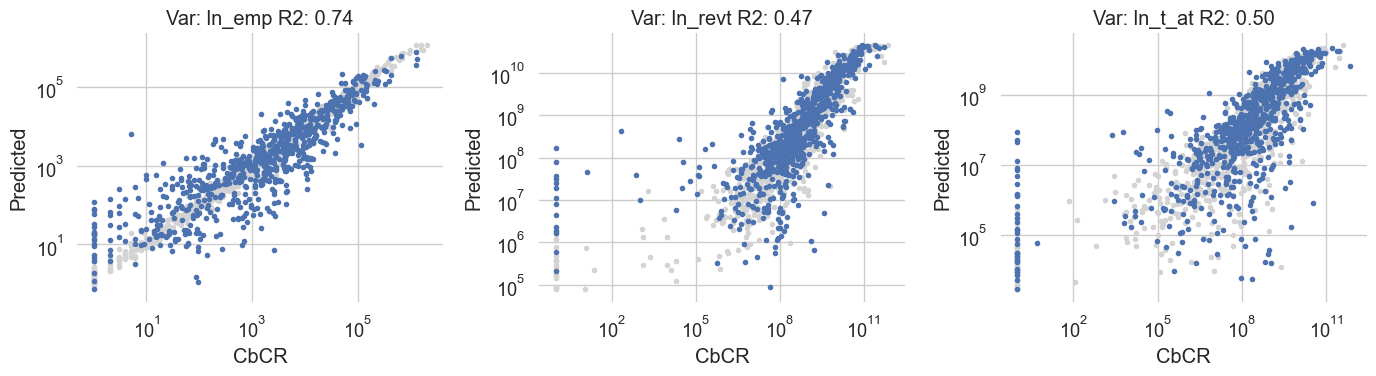

In [ ]:
plt.figure(figsize=(14,4))
for i,var in enumerate(["ln_emp","ln_revt","ln_t_at"]):
    est = HistGradientBoostingRegressor(**metaparameters[var])#(alpha=0.03)
    plt.subplot(1,3,i+1)
    plot_r2(est,df_foreign.dropna(subset=[var]),var)

plt.tight_layout()    
plt.savefig(f"{path_figures}/predicted_emp_revt.pdf")

## All pieces together

In [33]:
#cols = ['iso3_o','txc','ln_pi', 'ln_emp', 'ln_revt','ln_t_at','ln_cit_revenue_o', 'gdpcap_ppp_o', 'gatt_o', 'wto_o', 'entry_proc_o', 'entry_time_o', 'entry_tp_o', 'Physicians_per_1000_wb_o', 'Nurses_per_1000_wb_o', 'region_tjn_o', 'EU28_o', 'OECD_o', 'UKt_o', 'cit_o', 'ratings_o', 'english_o', 'Total FSI_o', 'ln_accountant_o', 'ln_all_tax_o', 'ln_banker_o', 'ln_ceo_o', 'ln_cfo_o', 'ln_coo_o', 'ln_cxo_o', 'ln_engineer_o', 'ln_other_corporate_o', 'ln_physician_o', 'ln_tax_compliance_audit_o', 'ln_transfer_pricing_o', 'ln_wealth_o', 'ln_audience_o', 'ln_consumption_o', 'ln_gfcf_o', 'ln_population_o', 'ln_uhnwi_o', 'ln_BIS_o', 'ln_finance_o', 'governance_o', 'ln_gdppc_o', 'tax_complex_o', 'cthi_o', 'etr_real_o', 'ln_etr_real_o', 'ln_pop_o', 'ln_gdp_o', 'ln_gdpcap_o', 'ln_gdp_ppp_o', 'ln_pop_pwt_o', 'ln_gdp_ppp_pwt_o', 'ln_entry_cost_o', 'ln_IP_payments_wb_o', 'ln_IP_receipts_wb_o', 'ln_FDI_inflows_WDI_wb_o', 'ln_Total_reserves_wb_o', 'ln_Number_of_new_businesses_registered_wb_o', 'ln_Imports_wb_o', 'ln_Exports_wb_o', 'ln_GDP_pc_wb_o', 'ln_GDP_deflator_wb_o', 'ln_Govt_exp_educ_gdp_wb_o', 'ln_Health_exp_gdp_wb_o', 'ln_GreenfieldFDI_outward_o', 'ln_GreenfieldFDI_inward_o', 'ln_resource_taxes_o', 'ln_total_taxes_revenue_o', 'ln_who_gvt_health_expenditure_o', 'ln_month_wage_o', 'ln_GDP_int_o', 'ln_POP_int_o', 'ln_Physicians_o', 'ln_Nurses_o', 'ln_n_companies_orb_o', 'gdp_ppp_o', 'pop_pwt_o', 'gdp_ppp_pwt_o', 'ln_cit_o']

df_domestic = df_pairs.loc[df_pairs["iso3_o"]==df_pairs["iso3_d"],domestic_variables]
df_foreign = df_pairs.loc[df_pairs["iso3_o"]!=df_pairs["iso3_d"]]


[IterativeImputer] Completing matrix with shape (213, 75)
[IterativeImputer] Ending imputation round 1/100, elapsed time 3.02
[IterativeImputer] Change: 83.96118931020706, scaled tolerance: 2.1091666666666664 
[IterativeImputer] Ending imputation round 2/100, elapsed time 4.52
[IterativeImputer] Change: 67.66661949530169, scaled tolerance: 2.1091666666666664 
[IterativeImputer] Ending imputation round 3/100, elapsed time 5.38
[IterativeImputer] Change: 23.81776317826647, scaled tolerance: 2.1091666666666664 
[IterativeImputer] Ending imputation round 4/100, elapsed time 6.33
[IterativeImputer] Change: 15.004717437872783, scaled tolerance: 2.1091666666666664 
[IterativeImputer] Ending imputation round 5/100, elapsed time 8.05
[IterativeImputer] Change: 10.418075736285564, scaled tolerance: 2.1091666666666664 
[IterativeImputer] Ending imputation round 6/100, elapsed time 9.54
[IterativeImputer] Change: 11.851740484372334, scaled tolerance: 2.1091666666666664 
[IterativeImputer] Ending i

,ln_pi,ln_emp,ln_revt,ln_t_at
index,,,,
ln_BIS_o,0.039477,0.646361,0.726130,1.284557
ln_gdp_o,0.082601,-0.168013,-0.011947,-0.227349
ln_population_o,0.082601,-0.168013,-0.011947,-0.227349
etr_real_o,0.082601,-0.168013,-0.011947,-0.227349
ln_n_companies_orb_o,0.158465,-0.582593,-0.104315,-0.590495


(10000000.0, 2000000000000.0)

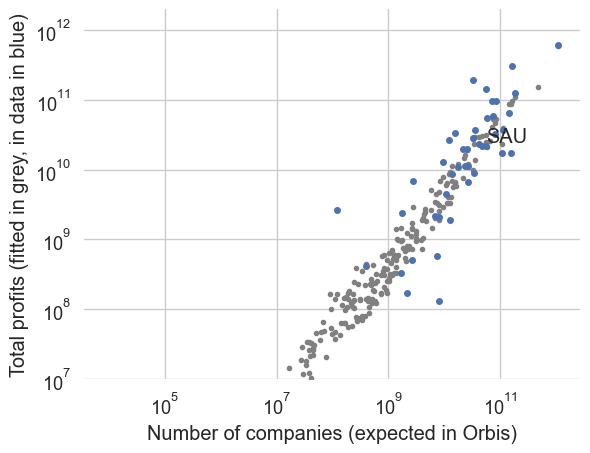

In [34]:
# #Predict domestic
# vars_use = df_domestic.count()
# vars_use = list(vars_use[vars_use>=len(df_domestic)*3/4].index)
# vars_use = [_ for _ in vars_use if "region" not in _]
vars_use = np.array(df_domestic.columns)[df_domestic.dtypes!=object]
vars_use = [_ for _ in vars_use if (_ not in df_fin.columns) and (_[3:] not in df_fin.columns)]

# vars_use = ['Physicians_per_1000_o', 'Nurses_per_1000_o', 'EU28_o', 'OECD_o', 'UKt_o', 'cit_o', 'ln_cit_o', 'ratings_o', 'english_o', 'Total FSI_o', 'ln_accountant_o', 'ln_all_tax_o', 'ln_banker_o', 'ln_ceo_o', 'ln_cfo_o', 'ln_coo_o', 'ln_cxo_o', 'ln_engineer_o', 'ln_other_corporate_o', 'ln_physician_o', 'ln_tax_compliance_audit_o', 'ln_transfer_pricing_o', 'ln_wealth_o', 'ln_audience_o', 'ln_consumption_o', 'ln_gfcf_o', 'ln_population_o', 'ln_uhnwi_o', 'ln_BIS_o', 'ln_finance_o', 'governance_o', 'ln_gdppc_o', 'tax_complex_o', 'cthi_o', 'etr_real_o', 'ln_etr_real_o', 'ln_pop_o', 'ln_gdp_o', 'ln_gdpcap_o', 'ln_entry_cost_o', 'ln_month_wage_o', 'ln_Health_expenditure_gdp_o', 'ln_govt_exp_educ_sgdp_wb_o', 'ln_resource_taxes_o', 'ln_total_taxes_revenue_o', 'ln_GDP_int_o', 'ln_POP_int_o', 'ln_Physicians_o', 'ln_Nurses_o', 'ln_etr_real_o', 'ln_n_companies_orb_o', 'ln_FDI_Inflows_WDI_o', 'ln_imports_wbd_o', 'ln_exports_wbd_o', 'ln_ip_payments_wbd_o', 'ln_ip_receipts_wbd_o']
dfx = impute(df_domestic,vars_use,verbose=5)
df_domestic_filled = fill_domestic(dfx,bootstrap=False,output=True,
                    columns =["ln_BIS_o","ln_gdp_o","ln_population_o", "etr_real_o","ln_n_companies_orb_o"])

v = "ln_n_companies_orb_o"
for c,x,y in zip(df_domestic_filled["iso3_o"],np.exp(df_domestic_filled[v]),np.exp(df_domestic_filled["fitted_ln_pi"])):
    if c == "SAU":
        plt.annotate(c,(x,y))
plt.plot(np.exp(df_domestic_filled[v]),np.exp(df_domestic_filled["fitted_ln_pi"]),".",color="gray")
plt.plot(np.exp(df_domestic_filled[v]),np.exp(df_domestic_filled["ln_pi"]),".",ms=8)
plt.xscale("log")
plt.yscale("log")
sns.despine(bottom=True,left=True)
plt.xlabel("Number of companies (expected in Orbis)")
plt.ylabel("Total profits (fitted in grey, in data in blue)")
plt.ylim(1E7,2E12)

Predictions for NLDs


,iso3_o,iso3_d,emp,pi,txc,revt,t_at,etr,ln_pi,ln_revt,ln_emp
1840,NLD,BEL,115241.0,3.892996e+09,4.441961e+08,3.686851e+10,9.792941e+09,0.114101,22.082445,24.330624,11.654790
1841,NLD,DEU,229237.0,6.541590e+09,2.015179e+09,9.026238e+10,4.745404e+10,0.308056,22.601446,25.225987,12.342516
1842,NLD,FJT,3438886.0,1.039607e+11,2.563629e+10,1.506168e+12,6.712564e+11,0.246596,25.367279,28.040590,15.050658
1843,NLD,GRPS,830935.0,2.629163e+10,3.514378e+09,4.852511e+11,2.244257e+11,0.133669,23.992517,26.907932,13.630308
1844,NLD,HKG,4544.0,4.573229e+08,1.221864e+08,9.188659e+09,5.248327e+08,0.267177,19.940900,22.941236,8.421783
1845,NLD,NLD,582272.0,2.177767e+10,4.238728e+09,3.088054e+11,1.246143e+11,0.194636,23.804151,26.455977,13.274695
1846,NLD,OAF,70195.0,4.394443e+09,2.133197e+09,2.191639e+10,2.330623e+10,0.485431,22.203607,23.810501,11.159047
1847,NLD,OAS,653143.0,2.953140e+10,1.013075e+10,3.104286e+11,1.376189e+11,0.343050,24.108720,26.461220,13.389553
1848,NLD,OTE,1416975.0,3.285296e+10,6.786842e+09,5.334670e+11,2.202965e+11,0.206582,24.215308,27.002663,14.164036
1849,NLD,POL,118616.0,1.904515e+09,4.895699e+08,1.878545e+10,7.837227e+09,0.257058,21.367493,23.656348,11.683655


,fitted_ln_pi,fitted_ln_emp,fitted_ln_revt,fitted_ln_t_at,ln_pi,ln_emp,ln_revt,ln_t_at
20544,3.048347e+10,680517.381757,3.473553e+11,2.558853e+11,2.177767e+10,582273.0,3.088054e+11,1.246143e+11


fitted_ln_pi      1.058558e+11
fitted_ln_emp     3.135991e+06
fitted_ln_revt    1.054027e+12
fitted_ln_t_at    4.579631e+11
dtype: float64

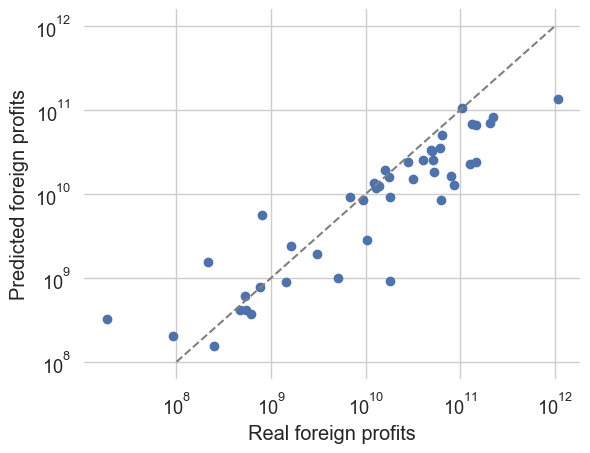

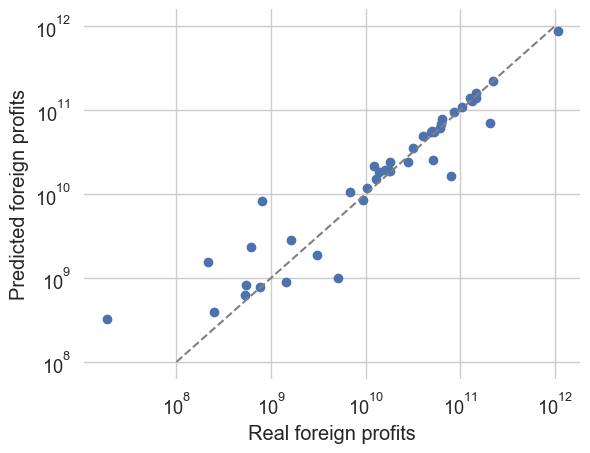

C:\Users\15671304\AppData\Local\Temp\ipykernel_22168\158718431.py:63: RuntimeWarning: divide by zero encountered in double_scalars
  scale_by = pred.sum().values/truth.values
C:\Users\15671304\AppData\Local\Temp\ipykernel_22168\158718431.py:63: RuntimeWarning: divide by zero encountered in double_scalars
  scale_by = pred.sum().values/truth.values
C:\Users\15671304\AppData\Local\Temp\ipykernel_22168\158718431.py:63: RuntimeWarning: divide by zero encountered in double_scalars
  scale_by = pred.sum().values/truth.values
C:\Users\15671304\AppData\Local\Temp\ipykernel_22168\158718431.py:63: RuntimeWarning: divide by zero encountered in double_scalars
  scale_by = pred.sum().values/truth.values
C:\Users\15671304\AppData\Local\Temp\ipykernel_22168\158718431.py:63: RuntimeWarning: divide by zero encountered in double_scalars
  scale_by = pred.sum().values/truth.values
C:\Users\15671304\AppData\Local\Temp\ipykernel_22168\158718431.py:64: RuntimeWarning: invalid value encountered in less
  sca

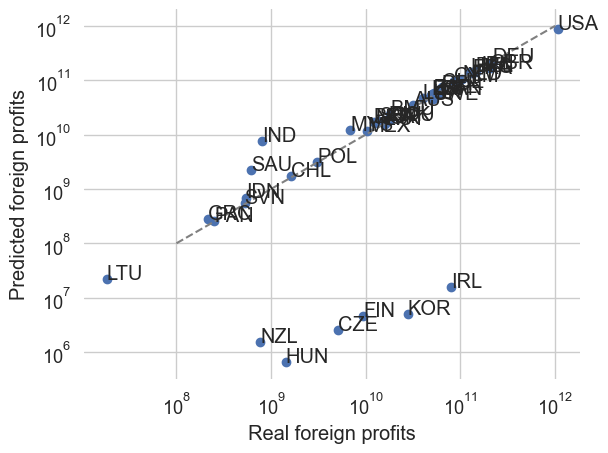

In [30]:
df_foreign.replace([np.inf, -np.inf], np.nan, inplace=True)
#Predict foreign
df_foreign_filled = fill_foreign(df_foreign,bootstrap=False,output=False)

#Check e.g. NLD
ground = df_fin.loc[df_fin["iso3_o"]=="NLD"]
for var in ["pi","revt","emp"]:
    ground["ln_"+var] = np.log(1+ground[var])
    
print("Predictions for NLDs")
display(ground)
display(np.exp(df_domestic_filled.loc[df_domestic_filled["iso3_o"]=="NLD",["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt","fitted_ln_t_at","ln_pi","ln_emp","ln_revt","ln_t_at"]]))
foreign_nl = df_foreign_filled.loc[df_foreign_filled["iso3_o"]=="NLD",["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt","fitted_ln_t_at"]]
display(np.exp(foreign_nl).sum().T)

# x = df_foreign_filled.loc[(df_foreign_filled["iso3_o"]=="NLD")&(df_foreign_filled["iso3_d"]!="NLD"),["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt"]]
# print(np.exp(x["fitted_ln_pi"]-1).sum()/1E9)

plot_matching_foreign(df_fin,df_foreign_filled)

##Fix the ones we know
for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
    df_foreign_filled.loc[~np.isnan(df_foreign_filled[var]),"fitted_"+var] = df_foreign_filled.loc[~np.isnan(df_foreign_filled[var]),var] 
    df_domestic_filled.loc[~np.isnan(df_domestic_filled[var]),"fitted_"+var] = df_domestic_filled.loc[~np.isnan(df_domestic_filled[var]),var] 
    

    #countries with no companies
    df_domestic_filled.loc[(df_domestic_filled["ln_n_companies_orb_o"]==0),"fitted_"+var] = 0
    df_foreign_filled.loc[df_foreign_filled["ln_n_companies_orb_o"]==0,"fitted_"+var] = 0

# x = df_foreign_filled.loc[(df_foreign_filled["iso3_o"]=="NLD")&(df_foreign_filled["iso3_d"]!="NLD"),["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt"]]
# print(np.exp(x["fitted_ln_pi"]-1).sum()/1E9)

plot_matching_foreign(df_fin,df_foreign_filled)

df_foreign_filled = [adjust_total(*_) for _ in df_foreign_filled.groupby("iso3_o")]
df_foreign_filled = pd.concat(df_foreign_filled)

# x = df_foreign_filled.loc[(df_foreign_filled["iso3_o"]=="NLD")&(df_foreign_filled["iso3_d"]!="NLD"),["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt"]]
# print(np.exp(x["fitted_ln_pi"]-1).sum()/1E9)

#small differences because we took out double counting
#data of brazil for FJT wrong (it does not affect the data, only this comparison)
plot_matching_foreign(df_fin,df_foreign_filled,annot=True)

for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
    df_foreign_filled.loc[:,var[3:]] = np.exp(df_foreign_filled["fitted_"+var])-1
    df_domestic_filled.loc[:,var[3:]] = np.exp(df_domestic_filled["fitted_"+var])-1
    

# 4 Bootstrap
- create function for bootstrapping

Remove duplicate columns in df_fin_mis to let boot() run (with duplicate column names, the pd.concat() in the boot() function won't work)

JAVIER DOES NOT HAVE THE FOLLOWING NEXT BLOCK AT ALL (HE EITHER DOES NOT HAVE DUPLICATE COLUMNS OR DOES NOT CARE ABOUT THEM), SO MAYBE TRY AROUND WITHOUT IT

In [31]:
unique_columns = df_fin_mis.columns.unique()
df_fin_mis = df_fin_mis[unique_columns]
unique_columns2 = df_fin.columns.unique()
df_fin = df_fin[unique_columns2]
unique_columns3 = df_domestic.columns.unique()
df_domestic = df_domestic[unique_columns3]
unique_columns4 = df_foreign.columns.unique()
df_foreign = df_foreign[unique_columns4]
unique_columns5 = df_domestic_filled.columns.unique()
df_domestic_filled = df_domestic_filled[unique_columns5]
unique_columns6 = df_foreign_filled.columns.unique()
df_foreign_filled = df_foreign_filled[unique_columns6]

In [32]:
def one_boot():
    """
    Fit the model
    
    Requires as global variables:
    - df_domestic
    - df_foreign
    - df_fin_mis
    - df_dom_remaining
    """
    
    ## DOMESTIC: Impute domestic data and fit model
    vars_use = np.array(df_domestic.columns)[df_domestic.dtypes!=object]
    vars_use = [_ for _ in vars_use if (_ not in df_fin.columns) and (_[3:] not in df_fin.columns)]

    dfx = impute(df_domestic,vars_use)
    df_domestic_filled = fill_domestic(dfx,bootstrap=True,output=False,
                        columns =["ln_BIS_o","ln_gdp_o","ln_population_o", "etr_real_o","ln_n_companies_orb_o"])

    ## FOREIGN: 
    # Impute fireign data and fit model
    df_foreign_filled = fill_foreign(df_foreign,bootstrap=True,output=False)

    
    # Correct the information that we know from the raw data
    for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
        df_foreign_filled.loc[~np.isnan(df_foreign_filled[var]),"fitted_"+var] = df_foreign_filled.loc[~np.isnan(df_foreign_filled[var]),var] 
        df_domestic_filled.loc[~np.isnan(df_domestic_filled[var]),"fitted_"+var] = df_domestic_filled.loc[~np.isnan(df_domestic_filled[var]),var] 

        #companies with no companies have no profits/etc
        df_domestic_filled.loc[(df_domestic_filled["ln_n_companies_orb_o"]==0),"fitted_"+var] = 0
        df_foreign_filled.loc[df_foreign_filled["ln_n_companies_orb_o"]==0,"fitted_"+var] = 0

    # Adjust the totals to match the groups
    df_foreign_filled = [adjust_total(*_) for _ in df_foreign_filled.groupby("iso3_o")]
    df_foreign_filled = pd.concat(df_foreign_filled)

    ## CREATE DATASET
    # Calculate the numbers from the logs
    for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
        df_foreign_filled.loc[:,var[3:]] = np.exp(df_foreign_filled["fitted_"+var])-1
        df_domestic_filled.loc[:,var[3:]] = np.exp(df_domestic_filled["fitted_"+var])-1

    # Use only the domestic data of the countries we have no information
    df_dom_remaining = df_domestic_filled.loc[~df_domestic_filled["iso3_o"].isin(df_fin_mis["iso3_o"].unique())]
    # make sure df_dom_remaining has unique columns
    #unique_columns7 = df_dom_remaining.columns.unique()
    #df_dom_remaining = df_dom_remaining[unique_columns7]

    # Merge the domestic data to the raw data
    #df_dom_remaining.reset_index(drop=True, inplace=True)
    #df_fin_mis.reset_index(drop=True, inplace=True)
    #df_calculate_mis = pd.concat([df_fin_mis, df_dom_remaining], sort=False, ignore_index=True)

    # @MIREK, MY MAIN PROBLEM APPEARS ABOVE.
    # WAY AROUND CONCAT PROBLEM: DEFINE df_calculate_mis = df_fin_mis (ignoring those values that would be substituted by df_dom_remaining)
    df_calculate_mis = df_fin_mis
    
    # Specify which rows correspond to domestic data
    df_calculate_mis["Domestic"] = (df_calculate_mis["iso3_o"]==df_calculate_mis["iso3_d"]).astype(int)

    
    ## ADJUST DATASET
    # Calculate the sum by destination country in the raw data
    df_misalignment = df_calculate_mis.copy()
    for var in ["emp","revt","t_at"]:
        df_misalignment[f"raw_{var}_sum"] = df_misalignment.groupby(["iso3_d","Domestic"])[var].transform(np.sum)
        df_misalignment[f"{var}_pred"] = df_misalignment[f"{var}"].copy()
    
    # Calculate the sum by destination country in the predicted data
    pred = df_foreign_filled.groupby("iso3_d")[["emp","revt","t_at"]].sum()
    pred.columns = ["emp_pred_sum","revt_pred_sum","t_at_pred_sum"]
    
    # Merge both to adjust
    pred = pd.merge(df_misalignment,pred.reset_index(),how="outer")   
    
    # Calculate the ratio between predicted and raw, and keep the lowest of the two values
    pred["extra_emp"] = (pred["emp_pred_sum"]+1)/(pred["raw_emp_sum"]+1).round(2)
    pred["extra_revt"] = (pred["revt_pred_sum"]+1)/(pred["raw_revt_sum"]+1).round(2)
    pred["one"] = 1
    pred["extra_top"] = pred[["one","extra_emp","extra_revt"]].max(1)
    pred["extra_max"] = pred[["extra_emp","extra_revt"]].max(1)    
    pred["extra"] = pred[["extra_emp","extra_revt"]].min(1)
    # If max is <1 don't adjust
    pred.loc[pred['extra_top']==1,"extra"] = pred.loc[pred['extra_top']==1,"extra_max"]
    # If max is >1 and min <1
    pred.loc[(pred['extra_max']>1)&(pred['extra']<1),"extra"] = 1
    # Cap the adjustment to 10
    pred.loc[pred["extra"]>10,"extra"] = 10#np.nan#Capped at 10 times 10# np.nan #Will remove that observation (during the correction step) when we are not capturing almost anything in the data
    # Don't adjust domestic data    
    pred.loc[pred["Domestic"]==1,"extra"] = 1
    
    # Perform adjustment
    pred["profits"] = pred["pi"]*pred["extra"]
    for var in ["emp","revt","t_at"]:
        pred[f"{var}_pred"] *= pred["extra"]
    
    # Return data
    return pred[["iso3_d","iso3_o","Domestic","emp_pred","revt_pred","t_at_pred","profits","extra","emp","revt","t_at","pi"]]

In [33]:
iso3_to_wages = pickle.load(open(iso3_to_wages_output,"rb+"))
iso3_to_cit = pickle.load(open(iso3_to_cit_output,"rb+"))

In [34]:
#Test with one ereplicate to see if everything looks okay

with np.errstate(divide='ignore', invalid='ignore'):
    r = one_boot()
iso3_to_dict = df_etrs.set_index("JUR")["ETR_total"].to_dict()
print(iso3_to_dict["HUN"])
r["etr"] = r["iso3_d"].map(iso3_to_dict)
r["wages"] = r["iso3_d"].map(iso3_to_wages)*r["emp"]
r["wages_pred"] = r["iso3_d"].map(iso3_to_wages)*r["emp_pred"]

df_misalignmentx = calculate_misalignment(r,
                                          pi_var="profits",
                           weights=[0,1/2,0,1/2],
                                          weights_var = ["revt_pred","emp_pred","t_at_pred","wages"]
                    )

r = df_misalignmentx.sort_values(by="misaligned_profits")
display(r.head(15))
display(r.tail(15))

0.1370908919113721
Profit shifted 1861.0 adjusted to 1731.2


,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,t_at,pi,etr,wages,wages_pred,share_emp_pred,share_wages,share_economy,share_profits,pi_theo_mis,misaligned_profits
371,USA,USA,1,2.374198e+07,1.132366e+13,5.981685e+12,6.102713e+11,1.000000,23741977.0,1.132366e+13,5.981685e+12,6.102713e+11,0.167340,1.044647e+11,1.044647e+11,0.185776,0.343313,0.264545,0.126681,1.274413e+12,-6.178058e+11
744,GBR,GBR,1,3.164742e+06,9.894753e+11,8.524017e+11,1.750596e+10,1.000000,3164742.0,9.894753e+11,8.524017e+11,1.750596e+10,0.082792,1.012912e+10,1.012912e+10,0.024763,0.033288,0.029026,0.003634,1.398290e+11,-1.137888e+11
718,FRA,FRA,1,3.422824e+06,1.126908e+12,6.979977e+11,6.363122e+10,1.000000,3422824.0,1.126908e+12,6.979977e+11,6.363122e+10,0.233692,1.162483e+10,1.162483e+10,0.026783,0.038204,0.032493,0.013209,1.565332e+11,-8.642033e+10
948,JPN,JPN,1,9.503979e+06,4.479168e+12,2.257655e+12,3.064754e+11,1.000000,9503979.0,4.479168e+12,2.257655e+12,3.064754e+11,0.281487,2.652526e+10,2.652526e+10,0.074367,0.087173,0.080770,0.063619,3.890986e+11,-7.685871e+10
611,DEU,DEU,1,4.178859e+06,1.533340e+12,1.144502e+12,1.254332e+11,1.000000,4178859.0,1.533340e+12,1.144502e+12,1.254332e+11,0.189484,1.505397e+10,1.505397e+10,0.032699,0.049473,0.041086,0.026038,1.979274e+11,-6.743632e+10
867,IND,IND,1,3.700776e+06,4.678100e+11,8.541785e+11,1.718669e+10,1.000000,3700776.0,4.678100e+11,8.541785e+11,1.718669e+10,0.413186,8.635206e+08,8.635206e+08,0.028958,0.002838,0.015898,0.003568,7.658597e+10,-5.525508e+10
878,IND,USA,0,2.134290e+06,9.253880e+10,4.413578e+10,1.459677e+10,1.338302,1594774.0,6.914640e+10,3.297893e+10,1.090693e+10,0.413186,3.721166e+08,4.980045e+08,0.016700,0.001223,0.008962,0.003030,4.317169e+10,-2.658129e+10
356,USA,FRA,0,7.409326e+05,2.981621e+11,7.404447e+10,1.220032e+10,1.069624,692704.0,2.787542e+11,6.922478e+10,1.140618e+10,0.167340,3.047898e+09,3.260104e+09,0.005798,0.010017,0.007907,0.002533,3.809171e+10,-2.408498e+10
208,ESP,ESP,1,1.206758e+06,3.685704e+11,5.045409e+11,2.173404e+10,1.000000,1206758.0,3.685704e+11,5.045409e+11,2.173404e+10,0.151626,2.938216e+09,2.938216e+09,0.009443,0.009656,0.009549,0.004512,4.600312e+10,-2.257586e+10
361,USA,JPN,0,1.000700e+06,8.210011e+11,3.219221e+11,3.285323e+10,1.069624,935563.0,7.675607e+11,3.009676e+11,3.071475e+10,0.167340,4.116477e+09,4.403082e+09,0.007830,0.013528,0.010679,0.006820,5.144649e+10,-1.729604e+10


,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,t_at,pi,etr,wages,wages_pred,share_emp_pred,share_wages,share_economy,share_profits,pi_theo_mis,misaligned_profits
1413,TWN,JPN,0,1.454361e+05,5.115609e+10,1.545443e+10,4.341663e+09,1.075282,135254.0,4.757460e+10,1.437245e+10,4.037699e+09,0.160292,NaN,NaN,1.138006e-03,NaN,NaN,9.012486e-04,NaN,NaN
1414,TWN,LUX,0,1.918303e+03,5.038636e+08,1.224751e+08,8.795192e+07,1.075282,1784.0,4.685875e+08,1.139005e+08,8.179430e+07,0.160292,NaN,NaN,1.501030e-05,NaN,NaN,1.825718e-05,NaN,NaN
1415,TWN,NOR,0,2.580676e+02,3.175844e+07,5.974265e+06,-2.322608e+05,1.075282,240.0,2.953500e+07,5.556000e+06,-2.160000e+05,0.160292,NaN,NaN,2.019323e-06,NaN,NaN,-4.821303e-08,NaN,NaN
1416,TWN,PER,0,7.387185e+02,3.730489e+08,5.293743e+07,2.785417e+07,1.075282,687.0,3.469313e+08,4.923122e+07,2.590407e+07,0.160292,NaN,NaN,5.780312e-06,NaN,NaN,5.782007e-06,NaN,NaN
1417,TWN,SGP,0,5.548453e+03,1.360360e+09,3.168823e+08,1.654233e+08,1.075282,5160.0,1.265120e+09,2.946970e+08,1.538418e+08,0.160292,NaN,NaN,4.341545e-05,NaN,NaN,3.433879e-05,NaN,NaN
1418,TWN,USA,0,1.683586e+06,3.707144e+10,2.206413e+10,4.053027e+09,1.075282,1565716.0,3.447603e+10,2.051939e+10,3.769270e+09,0.160292,NaN,NaN,1.317369e-02,NaN,NaN,8.413331e-04,NaN,NaN
1454,VGB,CHE,0,NaN,8.467920e+06,2.187325e+08,2.206585e+08,1.289445,NaN,6.567103e+06,1.696330e+08,1.711267e+08,0.004557,NaN,NaN,NaN,NaN,NaN,4.580460e-05,NaN,NaN
1557,COK,BMU,0,0.000000e+00,2.200000e+02,0.000000e+00,9.420909e+07,10.000000,0.0,2.200000e+01,0.000000e+00,9.420909e+06,0.000000,NaN,NaN,0.000000e+00,NaN,NaN,1.955606e-05,NaN,NaN
1558,COK,HKG,0,0.000000e+00,1.100000e+02,0.000000e+00,9.420272e+07,10.000000,0.0,1.100000e+01,0.000000e+00,9.420272e+06,0.000000,NaN,NaN,0.000000e+00,NaN,NaN,1.955473e-05,NaN,NaN
1559,COK,PER,0,0.000000e+00,4.922550e+06,0.000000e+00,-5.226889e+08,10.000000,0.0,4.922550e+05,0.000000e+00,-5.226889e+07,0.000000,NaN,NaN,0.000000e+00,NaN,NaN,-1.085005e-04,NaN,NaN


In [35]:
# 1000 replicates
with np.errstate(divide='ignore', invalid='ignore'), open(final_data_output,"w+") as f:
    for i in range(1000):
        print(i+1, end=": ")
        pred = one_boot()
        pred["n_rep"] = i
        
        pred.to_csv(f,sep="\t",index = None,header = i==0)

1: 2: 3: 4: 5: 6: 7: 8: 9: 10: 11: 12: 13: 14: 15: 16: 17: 18: 19: 20: 21: 22: 23: 24: 25: 26: 27: 28: 29: 30: 31: 32: 33: 34: 35: 36: 37: 38: 39: 40: 41: 42: 43: 44: 45: 46: 47: 48: 49: 50: 51: 52: 53: 54: 55: 56: 57: 58: 59: 60: 61: 62: 63: 64: 65: 66: 67: 68: 69: 70: 71: 72: 73: 74: 75: 76: 77: 78: 79: 80: 81: 82: 83: 84: 85: 86: 87: 88: 89: 90: 91: 92: 93: 94: 95: 96: 97: 98: 99: 100: 101: 102: 103: 104: 105: 106: 107: 108: 109: 110: 111: 112: 113: 114: 115: 116: 117: 118: 119: 120: 121: 122: 123: 124: 125: 126: 127: 128: 129: 130: 131: 132: 133: 134: 135: 136: 137: 138: 139: 140: 141: 142: 143: 144: 145: 146: 147: 148: 149: 150: 151: 152: 153: 154: 155: 156: 157: 158: 159: 160: 161: 162: 163: 164: 165: 166: 167: 168: 169: 170: 171: 172: 173: 174: 175: 176: 177: 178: 179: 180: 181: 182: 183: 184: 185: 186: 187: 188: 189: 190: 191: 192: 193: 194: 195: 196: 197: 198: 199: 200: 201: 202: 203: 204: 205: 206: 207: 208: 209: 210: 211: 212: 213: 214: 215: 216: 217: 218: 219: 220: 221: 222